In [1]:
import matplotlib.pyplot as plt
import numpy as np
from lmfit import Minimizer, Parameters
import sys
import pylab as py
import pandas as pd
import csv
import matplotlib.dates as mdates
from scipy import optimize, stats
from importlib import reload
import DataAnalysis.basic_functions as bf
import DataAnalysis.mod_expo_fit_functions as modf
import DataAnalysis.bi_fit_functions as bi_fit
import DataAnalysis.pulser_fit_functions as pf
import DataAnalysis.plot_functions as plotf

sys.path.append('/Users/arleeshelby/ManitobaWork_1374/pyNab/src')
import nabPy as Nab

In [2]:
with open('/Users/arleeshelby/Downloads/Runparameters10_10_12_03.csv') as f:
    csv.DictReader(f)
    metadata = pd.read_csv(f)

In [3]:
run_numbers = list(np.arange(8622,8633)) + list(np.arange(8635,8638)) + list(np.arange(8643,8660)) + list(np.arange(8681,8695)) + list(np.arange(8696,8700)) + list(np.arange(8704,8714)) + list(np.arange(8715,8722)) + list(np.arange(8824,8833))+list(np.arange(8834,8836)) + list(np.arange(8837,8851)) + list(np.arange(8853,8866))

In [4]:
UDETdata, UDETtime = bf.get_energy_time_data(run_numbers,'UDET')
LDETdata, LDETtime = bf.get_energy_time_data(run_numbers,'LDET')

In [5]:
UDETenergy = bf.get_energy(run_numbers,UDETdata)
LDETenergy = bf.get_energy(run_numbers,LDETdata)

In [6]:
UDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='UDET')
LDETdata_pulser, time_pulser = bf.get_energy_time_data(run_numbers,data_type='pulser',detector_type='LDET')

In [7]:
UDETenergy_pulser = bf.get_energy(run_numbers,UDETdata_pulser)
LDETenergy_pulser = bf.get_energy(run_numbers,LDETdata_pulser)

In [10]:
bin_edges = UDETdata[8715]['bin_edges']['0']['37']
bin_edges_pulser = UDETdata_pulser[8622]['bin_edges']['0']['60']
bin_edges_pulser112 = UDETdata_pulser[8622]['bin_edges']['0']['pulser BC 112']

In [374]:
LDETpixels = ['1009','1010','1011','1012','1013','1017','1018','1019','1020','1021','1022','1023','1026','1027','1028','1029','1030','1031','1032',
               '1033','1037','1038','1039','1040','1041','1042','1043','1044','1047','1048','1049','1050','1051','1052','1053','1054','1055','1056',
               '1060','1061','1062','1062','1063','1064','1065','1066','1067','1068','1069','1072','1073','1074','1075','1076','1077','1078','1079','1080',
               '1081','1084','1085','1086','1087','1088','1089','1090','1091','1092','1094','1095','1096','1098','1099','1100','1101','1102','1105',
               '1107','1108','1109','1111','1116','1117']

In [375]:
UDETpixels = ['9','11','12','17','19','20','21','26','27','28','29','30','31','32','37','38','39','40','41','42','43','47','48','49','50','51','52',
          '53','54','55','60','61','62','63','64','65','66','67','72','73','74','75','76','77','78','79','84','85','86','87','88','89','90','91',
          '94','95','96','97','98','99','100','101','102','105','106','107','108','109','110','115','117']

In [414]:
UDET_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, UDETenergy, bin_edges, UDETpixels, run_numbers, plot=False,detector_type='UDET')

failed Bi fit for run: 8647, pixel: 17, region 1
failed Bi fit for run: 8828, pixel: 17, region 1
failed Bi fit for run: 8847, pixel: 17, region 1
failed Bi fit for run: 8859, pixel: 19, region 1
run: 8630, pixel: 27 too low amp, region 1
failed Bi fit for run: 8689, pixel: 27, region 1
failed Bi fit for run: 8840, pixel: 27, region 1
run: 8624, pixel: 29 too low amp, region 2
failed Bi fit for run: 8834, pixel: 29, region 1
failed Bi fit for run: 8690, pixel: 30, region 1
failed Bi fit for run: 8690, pixel: 30, region 2
failed Bi fit for run: 8715, pixel: 37, region 1
failed Bi fit for run: 8624, pixel: 43, region 1
run: 8624, pixel: 43 too low amp, region 2
run: 8630, pixel: 43 too low amp, region 1
run: 8630, pixel: 43 too low amp, region 2
failed Bi fit for run: 8630, pixel: 43, region 3
run: 8637, pixel: 43 too low amp, region 1
failed Bi fit for run: 8637, pixel: 43, region 2
run: 8683, pixel: 43 too low amp, region 1
run: 8683, pixel: 43 too low amp, region 2
run: 8694, pixel: 4

In [ ]:
LDET_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, LDETenergy, bin_edges, LDETpixels, run_numbers, plot=False,detector_type='LDET')

failed Bi fit for run: 8720, pixel: 1011, region 1
failed Bi fit for run: 8720, pixel: 1011, region 3
failed Bi fit for run: 8826, pixel: 1011, region 1
failed Bi fit for run: 8826, pixel: 1011, region 3
failed Bi fit for run: 8857, pixel: 1011, region 3
LDET average too low, run 8644, pixel 1012
failed Bi fit for run: 8644, pixel: 1012, region 2
LDET average too low, run 8697, pixel 1012
run: 8697, pixel: 1012 too low amp, region 2
failed Bi fit for run: 8719, pixel: 1012, region 1
run: 8829, pixel: 1012 too low amp, sig1 or sig2 region 1
LDET average too low, run 8863, pixel 1012
failed Bi fit for run: 8863, pixel: 1012, region 2
LDET average too low, run 8626, pixel 1013
failed Bi fit for run: 8626, pixel: 1013, region 2
failed Bi fit for run: 8626, pixel: 1013, region 3
LDET average too low, run 8644, pixel 1013
LDET average too low, run 8651, pixel 1013
LDET average too low, run 8685, pixel 1013
failed Bi fit for run: 8685, pixel: 1013, region 2
LDET average too low, run 8697, pix

In [482]:
# test_runs = [8622,8623,8624,8637,8649,8654,8684,8685,8689,8690,8706,8716,8830,8835,8837,8845,8850,8860]
# test_pixels = ['20','27','30','32','43','64','66','72','87','89','95','109','110']
test_runs = [8622,8624,8635,8659,8682,8706,8834,8839,8848,8849,8861]
test_pixels = ['29','43','48','54','63','64','94','100','109']

In [708]:
# UDET_test_df = bf.get_results_df(bi_fit.get_UDETbi_fit_results, UDETenergy, bin_edges, test_pixels, test_runs, plot=True,detector_type='UDET')

In [415]:
simulated_keV_values = np.array([22.269661+3,35.276915+3,450.020179+3,522.714534+3,535.039+3,
                                 944.193705+3,1016.613371+3,1029.008589+3])
simulated_keV_errors = np.array([0.005846,0.002800,0.003731,0.005186,0.013013,0.002459,0.004933,0.012757])

In [416]:
calibration_peak_data,calibration_width_data,calibration_amp_data = bf.get_cal_peaks_df(UDET_df,simulated_keV_values,simulated_keV_errors)

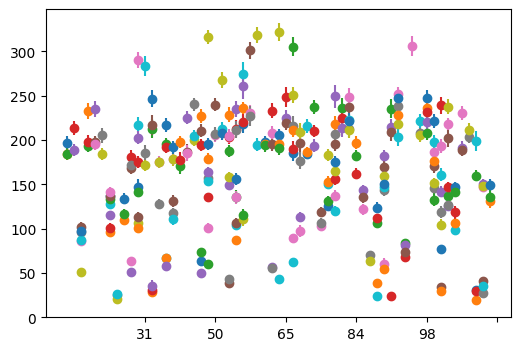

In [724]:
plotf.plot_peak_fit_params(calibration_amp_data,peak='peak3',bottom_ylim=0,top_ylim=None)

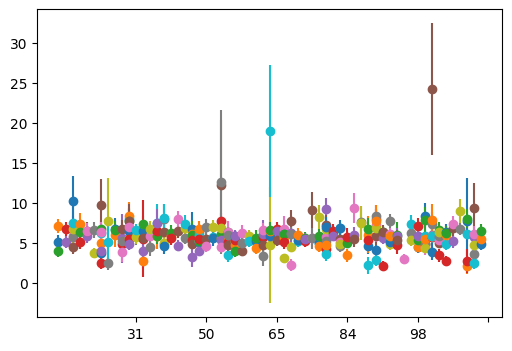

In [725]:
plotf.plot_peak_fit_params(calibration_width_data,peak='peak5',bottom_ylim=None,top_ylim=None)

In [727]:
calibration_linear_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='linear')
calibration_quadratic_results = bf.calibrate_data(calibration_peak_data,calibration_amp_data,calibration_order='quadratic')

In [728]:
keys = list(calibration_linear_results.keys())
runs_calibrated = []
for i in keys:
    runs = list(calibration_linear_results[i].keys())
    for j in range(len(runs)):
        if any(value==str(runs[j]) for value in runs_calibrated):
            pass
        else:
            runs_calibrated.append(str(runs[j]))

In [729]:
runs_calibrated
with open('DatabaseFiles/Runs/calibrated_runs.txt', 'w') as file:
    file.write('\n'.join(runs_calibrated))

In [731]:
with open('DatabaseFiles/Runs/run_db.csv') as f:
    csv.DictReader(f)
    metadata = pd.read_csv(f)

In [732]:
metadata

,run_number,UDET_bias,LDET_bias,HV,MAIN,UDET,date,start_time,end_time,ExB,UDET_armor,UDET_ring,LDET_armor,UDET_leakage,LDET_leakage
0,8655,300.0,300.0,27.0,137.0,137.0,2025-10-14,20:51:38,20:51:36,-1499.050847,134.458618,119.984912,129.964194,0.007057,35.94986
1,8709,300.0,300.0,27.0,137.0,137.0,2025-10-21,19:48:30,19:48:28,-1499.000000,134.458499,119.991606,129.974482,0.007585,35.96716
2,8855,300.0,300.0,27.0,137.0,137.0,2025-10-31,15:31:48,15:31:46,-1499.117949,134.275259,120.013290,130.077537,0.007338,35.86735
3,8646,300.0,300.0,27.0,137.0,137.0,2025-10-14,15:35:23,15:35:21,-1499.078125,134.468330,119.999757,129.926447,0.007080,35.94495
4,8848,300.0,300.0,27.0,137.0,137.0,2025-10-30,20:20:45,20:20:43,-1499.000000,134.306473,120.004832,130.048831,0.007573,35.63690
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,8720,300.0,300.0,27.0,137.0,137.0,2025-10-22,16:18:29,16:50:08,-1499.028090,134.445196,120.003004,130.028883,0.007329,36.64413
100,8826,300.0,300.0,27.0,137.0,137.0,2025-10-29,19:53:08,20:23:09,-1499.386364,134.329690,119.994170,130.084202,0.008578,36.42743
101,8857,300.0,300.0,27.0,137.0,137.0,2025-10-31,16:42:53,17:17:46,-1499.062802,134.281502,120.014718,130.094448,0.007322,36.35307
102,8719,300.0,300.0,27.0,137.0,137.0,2025-10-22,15:45:26,16:15:26,-1499.269962,134.445041,120.003693,130.040813,0.007344,36.53752


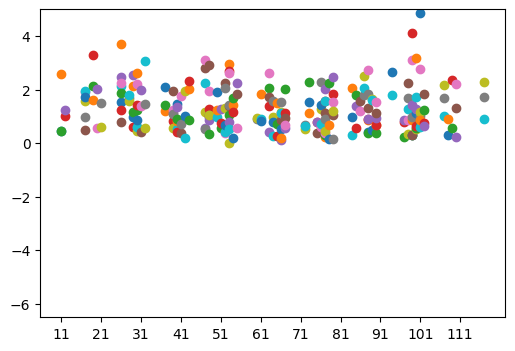

In [736]:
plotf.plot_goodness_of_fit(calibration_linear_results,chi2=False,reduced_chi2=True,bottom_ylim=None,top_ylim=5)

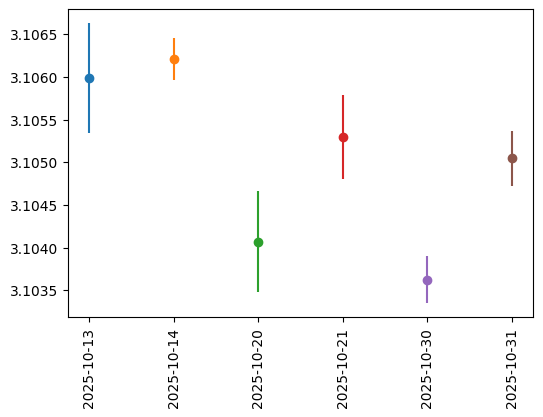

In [741]:
plotf.plot_calibration_results('52',calibration_linear_results,metadata,gain=True)

In [742]:
gain = bf.get_calibration_fit_params(calibration_linear_results,gain=True)
offset = bf.get_calibration_fit_params(calibration_linear_results,offset=True)

In [743]:
average_gain, average_gain_error, gain_std = bf.get_calibration_param_props(gain)
average_gain_weighted, average_gain_error_weighted, gain_std_weighted = bf.get_calibration_param_props(gain,weighted=True)

average_offset, average_offset_error, offset_std = bf.get_calibration_param_props(offset)
average_offset_weighted, average_offset_error_weighted, offset_std_weighted = bf.get_calibration_param_props(offset,weighted=True)

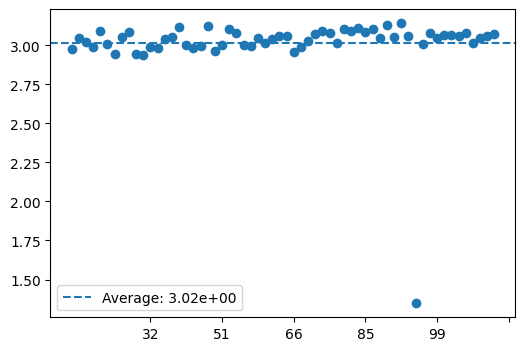

In [745]:
plotf.plot_calibration_param_props(average_gain_weighted)

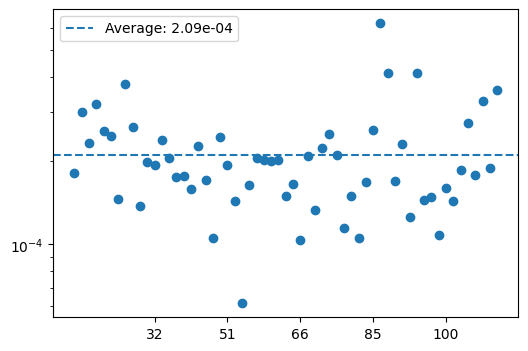

In [747]:
plot_calibration_param_props(gain_std_weighted,yscale='log')

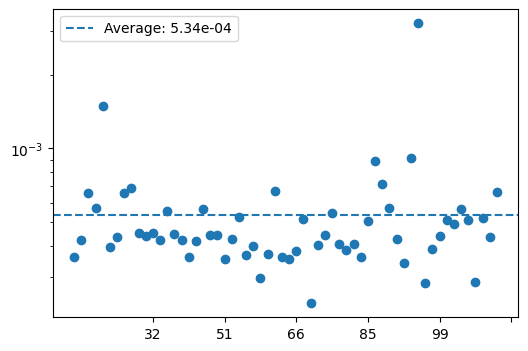

In [749]:
plot_calibration_param_props(average_gain_error,yscale='log')

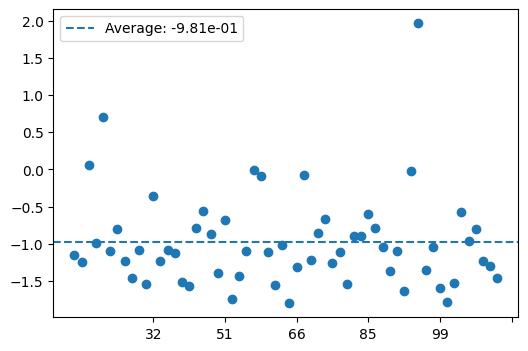

In [751]:
plot_calibration_param_props(average_offset_weighted)

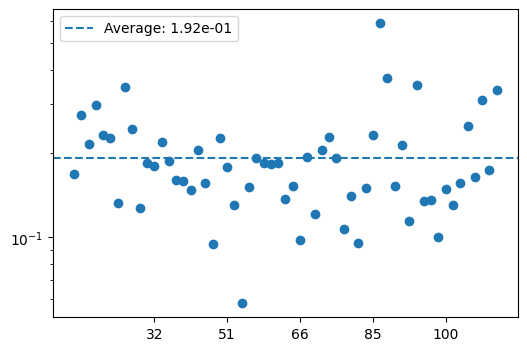

In [754]:
plot_calibration_param_props(offset_std_weighted,yscale='log')

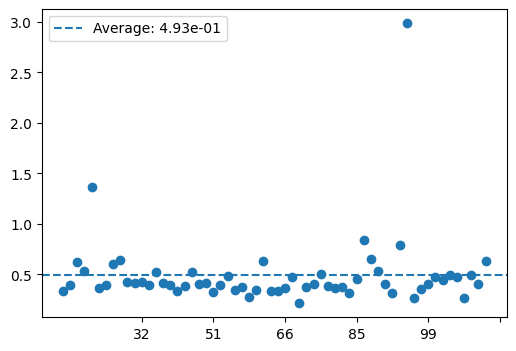

In [755]:
plot_calibration_param_props(average_offset_error)